
distribution:
- 521 ppl use claude
- 17327 people didn't answer
- assume 90% of these don't answer again (they are putting 0)
10% of these go into AI category
- 255+118+145 people are somehow clustured as a normal distribution with a flat curve (maybe another AI)
- 1790 people have applied brain
- 123 people have applied wrong brain
-- 4803 people have done something, in which 2952 people have done above things
- so, 1851 people are distributed as noise
assum 20% of these go to ai buckets
rest are noise

that gives:
706 [0.108] people who will use claude - claude is saying put 0.36 rounded as 30. Say 70% (495) [0.0757] put 0.36 and 30% (211) [0.0323] put 0.3
assume 80% [0.0861] people put claude answer as it is, and 20% [0.0215] are distributed on the tail (skew normal distribution) cuz they figure that at the loss of slightly higher bid they will get better rank.
703 [0.1077] people use chatGPT (some other AI), 80% [0.0861] put as it is, 20% [0.0215] put slightly higher - chatgpt says 0.3
1790 [0.274] pppl who applied brain - say 15% [0.0411] thought it was best to settle for 0 and 5% [0.0137] thought to put a high number (0.8)and optimise on other two parameters, 10% [0.0274] of people are doing what i am doing (at the end calculate best distribution and distribute these 20% with skew normal nd that), 50% (895) [0.1377] put 0.4, 20% (358) [0.0543] put 0.8
123 [0.0189] people put 0.5 - skew normal
1480 [0.2269] people put nice numbers
1733 [0.2656] as absolute noise


0.0757 - normal about 36
0.0323 - normal about 30
0.1077 - normal about 30
0.0411 - skew-normal fat right about 0
0.0137 - normal about 80
0.1377 - normal about 40
0.0543 - normal about 50
0.0189 - skew-normal with fatter right about 50
0.2269 - normal distributions on all multiples of 10
0.2656 - uniform noise
0.1064 - skew-normal with fat left about 26.03


# 0.0274 - normal about 41, 80

In [2]:
import sys, math, importlib
import numpy as np
import matplotlib.pyplot as plt
import distribution
importlib.reload(distribution)
from scipy.optimize import brentq

def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * (x / 100)

_i_vals = np.arange(1, 10001) / 100
_sfv = distribution.mixture_cdf(_i_vals) * 0.8 + 0.1

def speed_func(idx):
    return _sfv[idx - 1]

def f(x, t):
    if x <= -1.0:
        raise ValueError()
    return (t - x) / (1.0 + x) - math.log1p(x)

def bracket_root(t, x0=0.0, step=1.0, max_expand=200):
    a = max(x0 - step, -1.0 + 1e-12)
    b = x0 + step
    fa, fb = f(a, t), f(b, t)
    for _ in range(max_expand):
        if fa * fb < 0.0:
            return a, b
        if fa > 0.0:
            b += step
            fb = f(b, t)
        else:
            a = max(-1.0 + (1.0 + a) * 0.5, -1.0 + 1e-15)
            fa = f(a, t)
        step *= 1.5
    raise RuntimeError(f'No bracket for t={t}')

def solve(t):
    a, b = bracket_root(t)
    return brentq(f, a, b, args=(t,), xtol=1e-12, rtol=1e-12)

speed, best_pnls, worst_pnls, risktoreward, prediction = [], [], [], [], []
for i in range(1, 10001):
    iv = i / 100
    x = solve(iv)
    rval = research(x) * scale(iv - x)
    best_pnls.append(0.9 * rval - 50000)
    worst_pnls.append(0.1 * rval - 50000)
    predicted = speed_func(100 - i) * rval - 50000
    prediction.append(predicted)
    speed.append(100 - iv)
    risktoreward.append(max(0, predicted / (-worst_pnls[-1])))

speed_arr = np.array(speed)
best_arr  = np.array(best_pnls)
worst_arr = np.array(worst_pnls)
rr_arr    = np.array(risktoreward)
pred_arr  = np.array(prediction)

def zero_crossing(x, y):
    idx = np.where(np.diff(np.sign(y)))[0][0]
    return x[idx] + (x[idx+1]-x[idx]) * (-y[idx] / (y[idx+1]-y[idx]))

best_zero  = zero_crossing(speed_arr, best_arr)
worst_zero = zero_crossing(speed_arr, worst_arr)
rr_zero    = zero_crossing(speed_arr, rr_arr)
rr_max_x   = speed_arr[np.argmax(rr_arr)]
h_val      = worst_arr[speed_arr == 0][0]
diff_h     = best_arr - h_val
_hi        = np.where(np.diff(np.sign(diff_h)))[0][0]
x_h_best   = (speed_arr[_hi]
               + (speed_arr[_hi+1] - speed_arr[_hi])
               * (-diff_h[_hi] / (diff_h[_hi+1] - diff_h[_hi])))
pred_max_idx = np.argmax(pred_arr)
pred_max_x   = speed_arr[pred_max_idx]
pred_max_y   = pred_arr[pred_max_idx]

def _base():
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(speed, best_pnls,  label='Best PnL')
    ax1.plot(speed, worst_pnls, label='Worst PnL')
    ax1.set_ylabel('PnL')
    return fig, ax1

def _legend(ax1, ax2=None):
    l1, lab1 = ax1.get_legend_handles_labels()
    if ax2 is not None:
        l2, lab2 = ax2.get_legend_handles_labels()
        ax1.legend(l1 + l2, lab1 + lab2, fontsize=8)
    else:
        ax1.legend(fontsize=8)

print('Setup complete.')

Setup complete.


In [3]:
solve(57)
print("ghello", worst_pnls[4300])

ghello -25857.609786293917


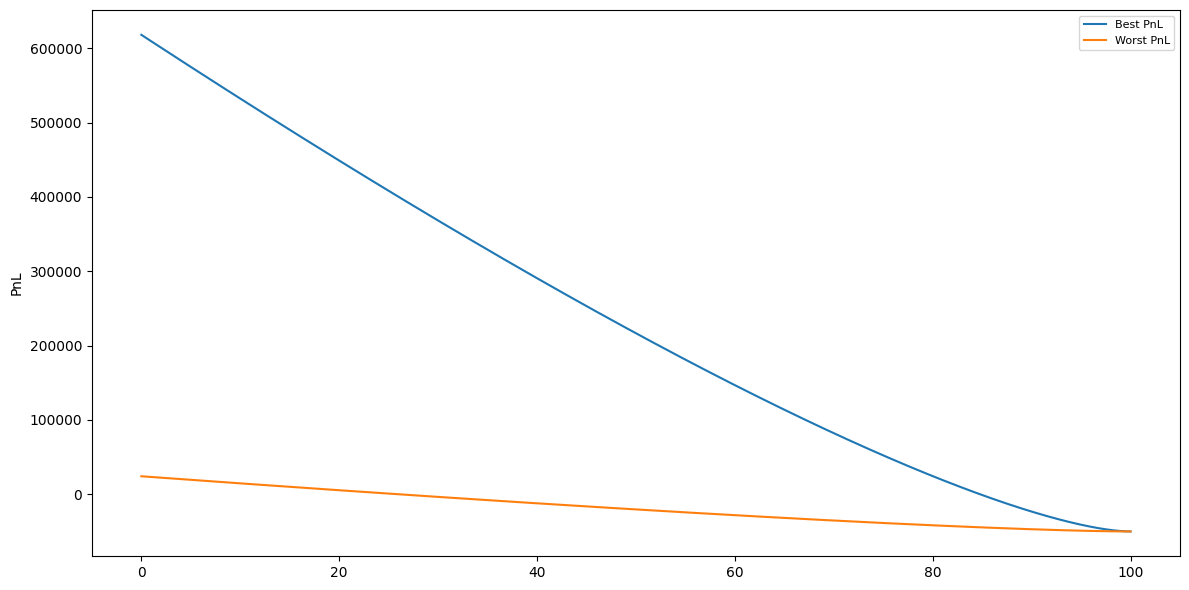

In [4]:
fig, ax1 = _base()
_legend(ax1)
plt.tight_layout()
plt.show()

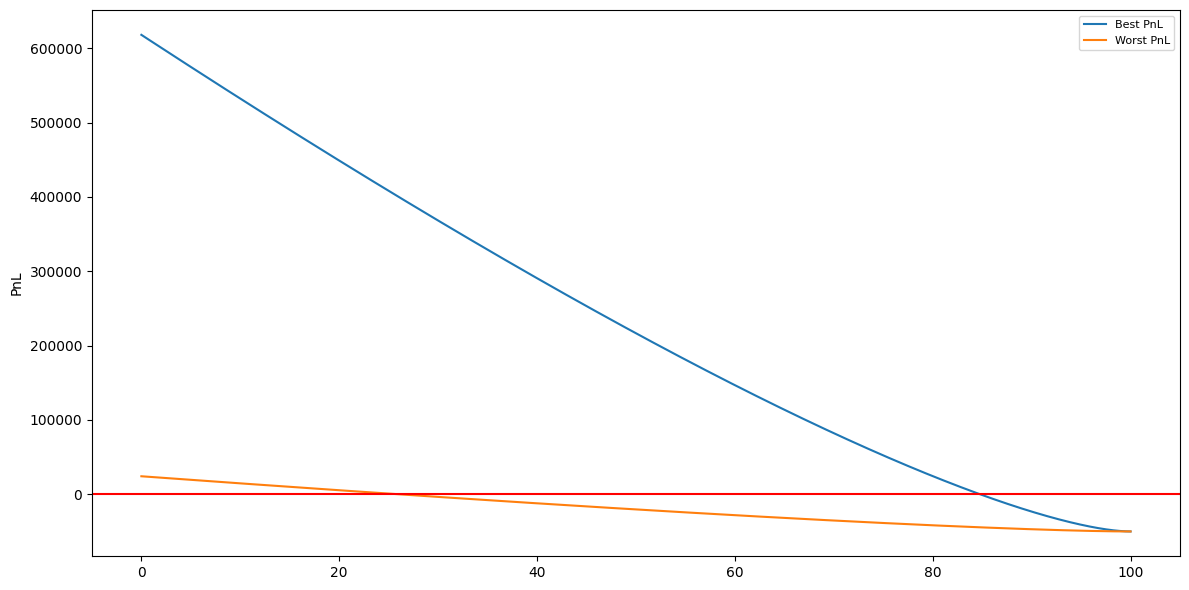

In [5]:
fig, ax1 = _base()
ax1.axhline(y=0, color='r', linestyle='-')
_legend(ax1)
plt.tight_layout()
plt.show()

Best PnL  = 0  at speed = 84.7823
Worst PnL = 0  at speed = 26.0213


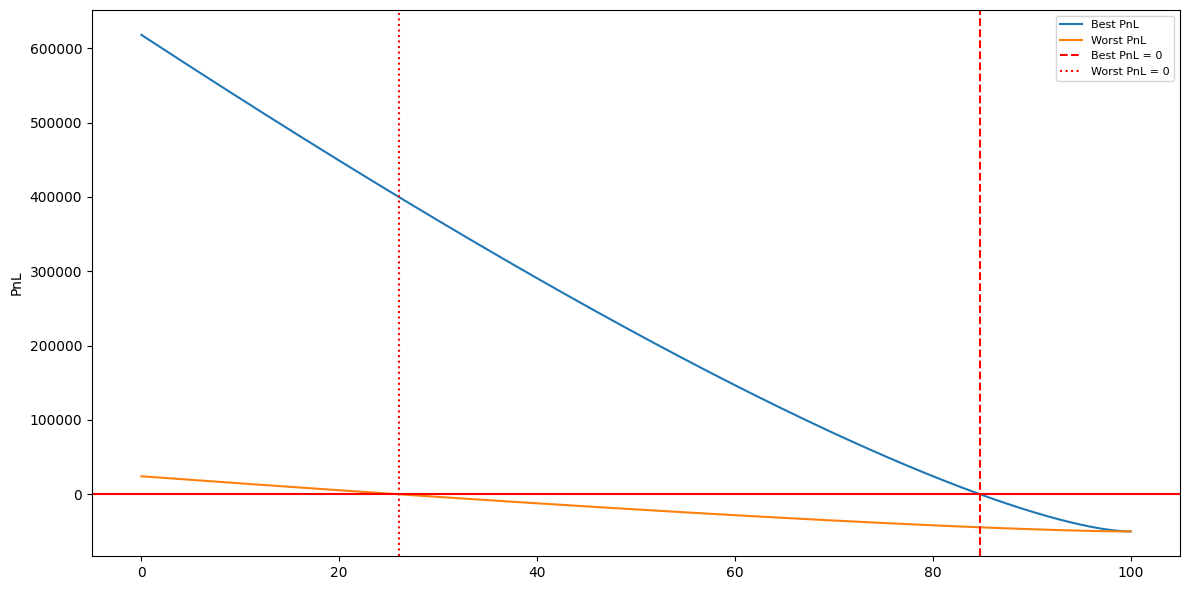

In [6]:
fig, ax1 = _base()
ax1.axhline(y=0, color='r', linestyle='-')
ax1.axvline(x=best_zero,  color='red', linestyle='--', label='Best PnL = 0')
ax1.axvline(x=worst_zero, color='red', linestyle=':',  label='Worst PnL = 0')
print(f'Best PnL  = 0  at speed = {best_zero:.4f}')
print(f'Worst PnL = 0  at speed = {worst_zero:.4f}')
_legend(ax1)
plt.tight_layout()
plt.show()

Max R/R  at speed = 26.0300
R/R = 0  at speed = 84.1000


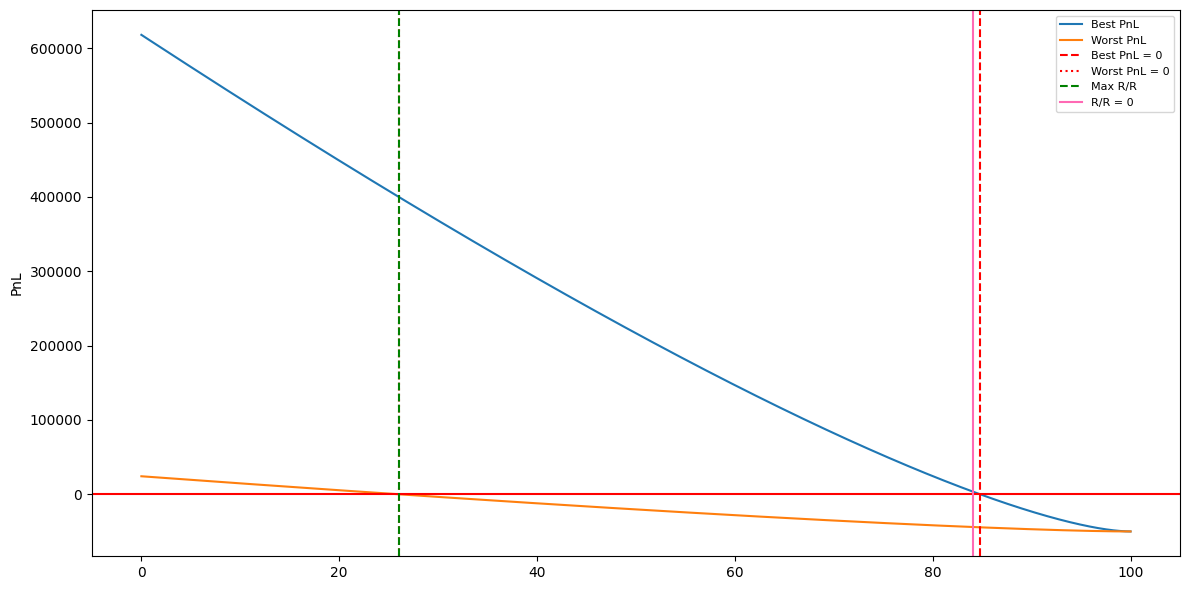

In [7]:
fig, ax1 = _base()
ax1.axhline(y=0, color='r', linestyle='-')
ax1.axvline(x=best_zero,  color='red', linestyle='--', label='Best PnL = 0')
ax1.axvline(x=worst_zero, color='red', linestyle=':',  label='Worst PnL = 0')
ax1.axvline(x=rr_max_x,   color='green',   linestyle='--', label='Max R/R')
ax1.axvline(x=rr_zero,    color='hotpink', linestyle='-',  label='R/R = 0')
print(f'Max R/R  at speed = {rr_max_x:.4f}')
print(f'R/R = 0  at speed = {rr_zero:.4f}')
_legend(ax1)
plt.tight_layout()
plt.show()

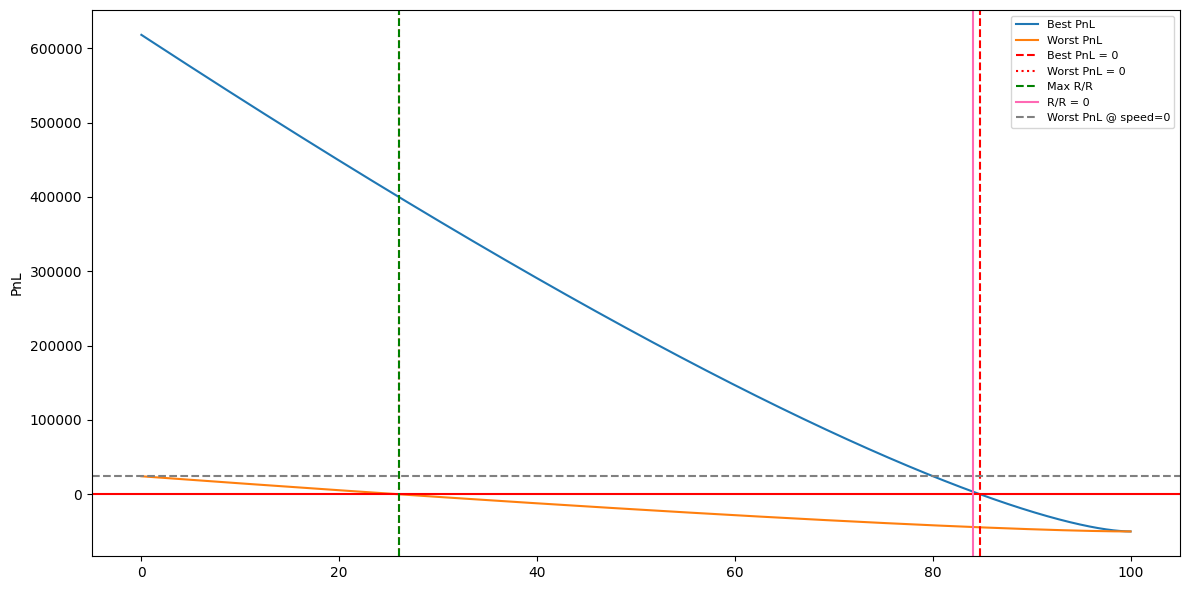

In [8]:
fig, ax1 = _base()
ax1.axhline(y=0, color='r', linestyle='-')
ax1.axvline(x=best_zero,  color='red', linestyle='--', label='Best PnL = 0')
ax1.axvline(x=worst_zero, color='red', linestyle=':',  label='Worst PnL = 0')
ax1.axvline(x=rr_max_x,   color='green',   linestyle='--', label='Max R/R')
ax1.axvline(x=rr_zero,    color='hotpink', linestyle='-',  label='R/R = 0')
ax1.axhline(y=h_val, color='gray', linestyle='--', label='Worst PnL @ speed=0')
_legend(ax1)
plt.tight_layout()
plt.show()

Best PnL = Worst@speed=0  at speed = 80.0281


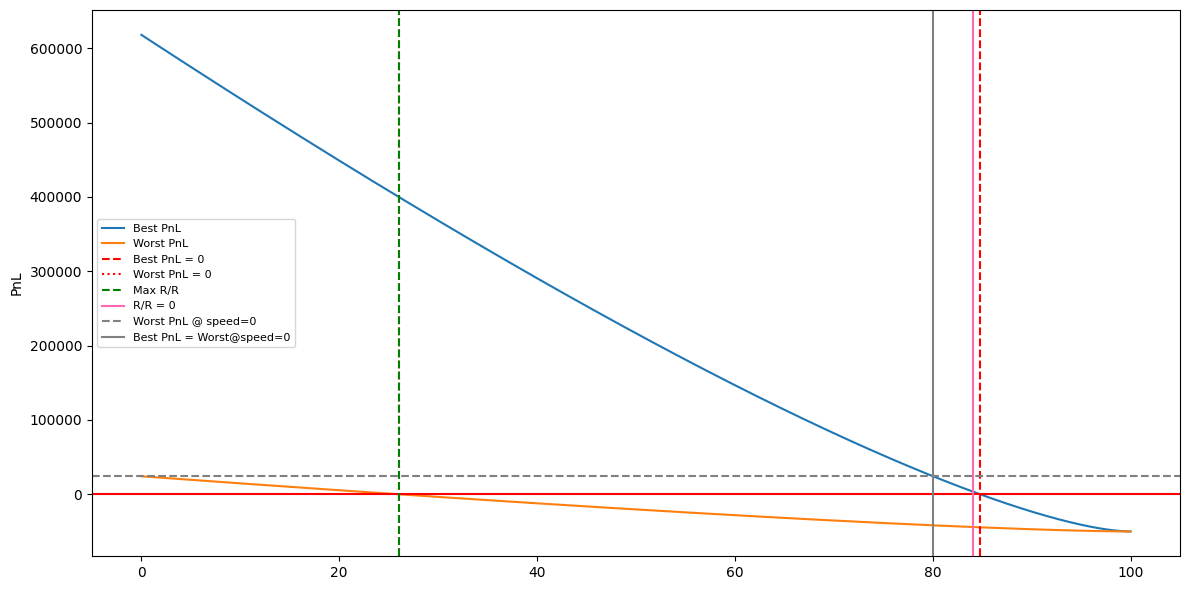

In [9]:
fig, ax1 = _base()
ax1.axhline(y=0, color='r', linestyle='-')
ax1.axvline(x=best_zero,  color='red', linestyle='--', label='Best PnL = 0')
ax1.axvline(x=worst_zero, color='red', linestyle=':',  label='Worst PnL = 0')
ax1.axvline(x=rr_max_x,   color='green',   linestyle='--', label='Max R/R')
ax1.axvline(x=rr_zero,    color='hotpink', linestyle='-',  label='R/R = 0')
ax1.axhline(y=h_val, color='gray', linestyle='--', label='Worst PnL @ speed=0')
ax1.axvline(x=x_h_best, color='gray', linestyle='-', label='Best PnL = Worst@speed=0')
print(f'Best PnL = Worst@speed=0  at speed = {x_h_best:.4f}')
_legend(ax1)
plt.tight_layout()
plt.show()

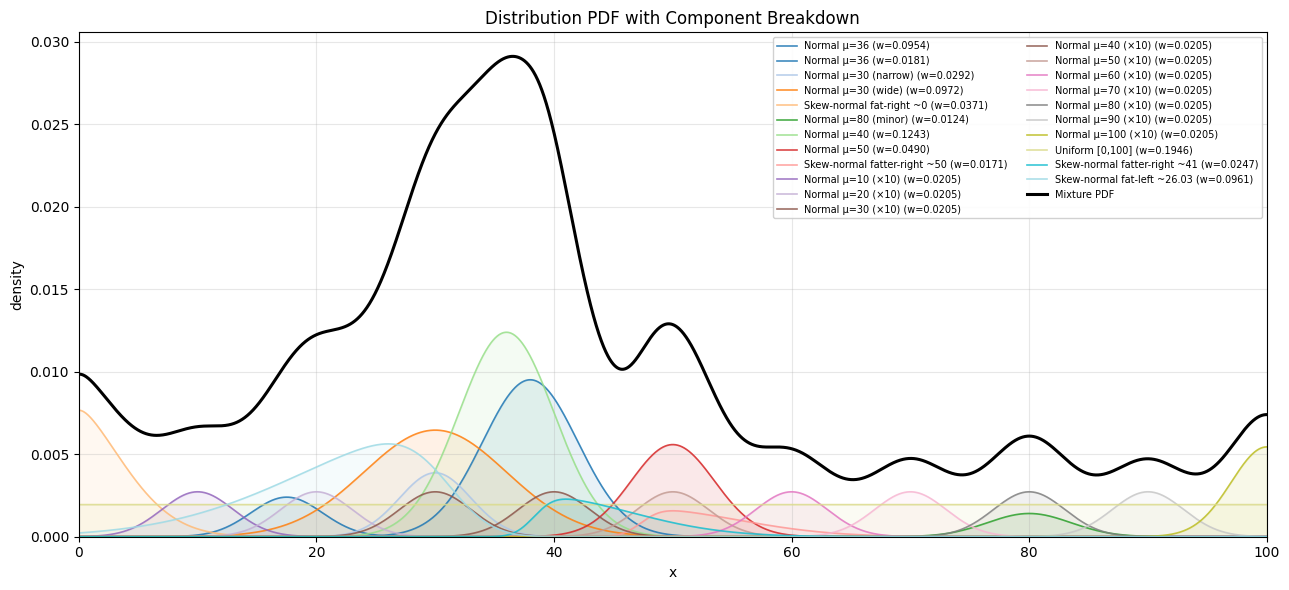

In [10]:
from matplotlib import cm
x_grid = np.linspace(0, 100, 4001)
pdf_vals = distribution.mixture_pdf(x_grid)
colors = [cm.tab20(i / len(distribution.COMPONENTS)) for i in range(len(distribution.COMPONENTS))]

fig, ax = plt.subplots(figsize=(13, 6))
for p, c in zip(distribution.COMPONENTS, colors):
    y = np.where((x_grid >= 0) & (x_grid <= 100),
                 p['s'] * distribution.component_pdf(p, x_grid), 0.0)
    ax.plot(x_grid, y, color=c, lw=1.2, alpha=0.85, label=f"{p['label']} (w={p['w']:.4f})")
    ax.fill_between(x_grid, 0, y, color=c, alpha=0.10)
ax.plot(x_grid, pdf_vals, color='black', lw=2.2, label='Mixture PDF')
ax.set_title('Distribution PDF with Component Breakdown')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=7, framealpha=0.9, ncol=2)
plt.tight_layout()
plt.show()

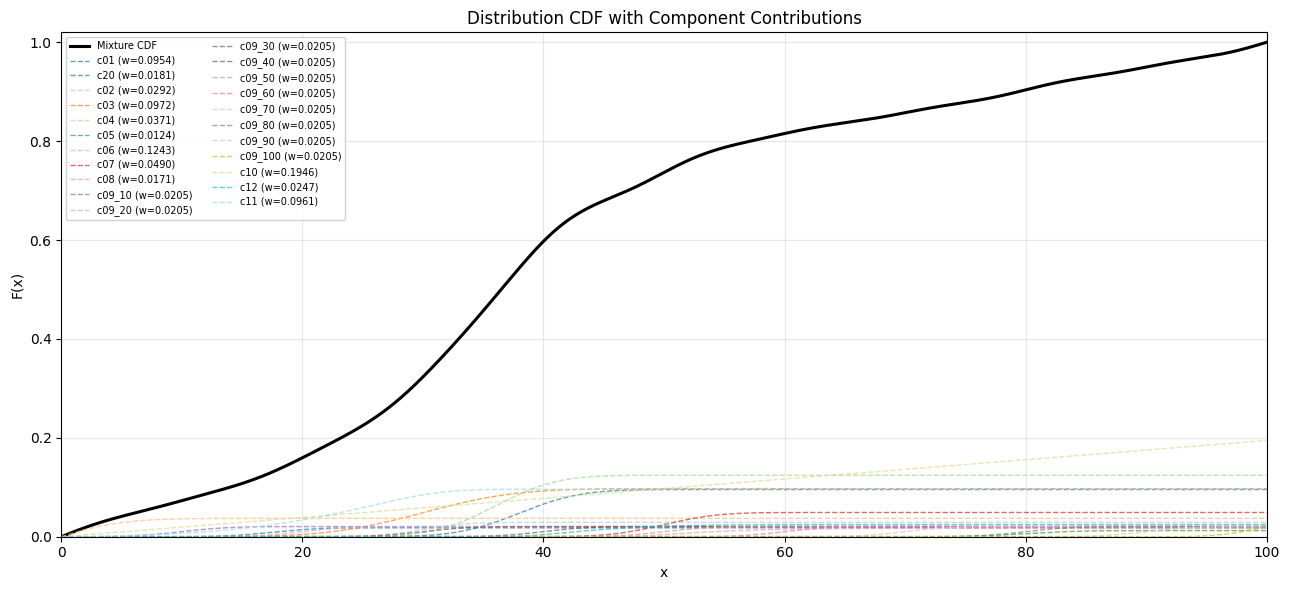

In [11]:
from matplotlib import cm
x_grid = np.linspace(0, 100, 4001)
cdf_vals = distribution.mixture_cdf(x_grid)
colors = [cm.tab20(i / len(distribution.COMPONENTS)) for i in range(len(distribution.COMPONENTS))]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(x_grid, cdf_vals, color='black', lw=2.2, label='Mixture CDF')
for p, c in zip(distribution.COMPONENTS, colors):
    contrib = p['s'] * (distribution.component_cdf(p, x_grid) - p['cdf_lo'])
    ax.plot(x_grid, contrib, color=c, lw=1.0, alpha=0.7, ls='--',
            label=f"{p['key']} (w={p['w']:.4f})")
ax.set_title('Distribution CDF with Component Contributions')
ax.set_xlabel('x')
ax.set_ylabel('F(x)')
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=7, framealpha=0.9, ncol=2)
plt.tight_layout()
plt.show()

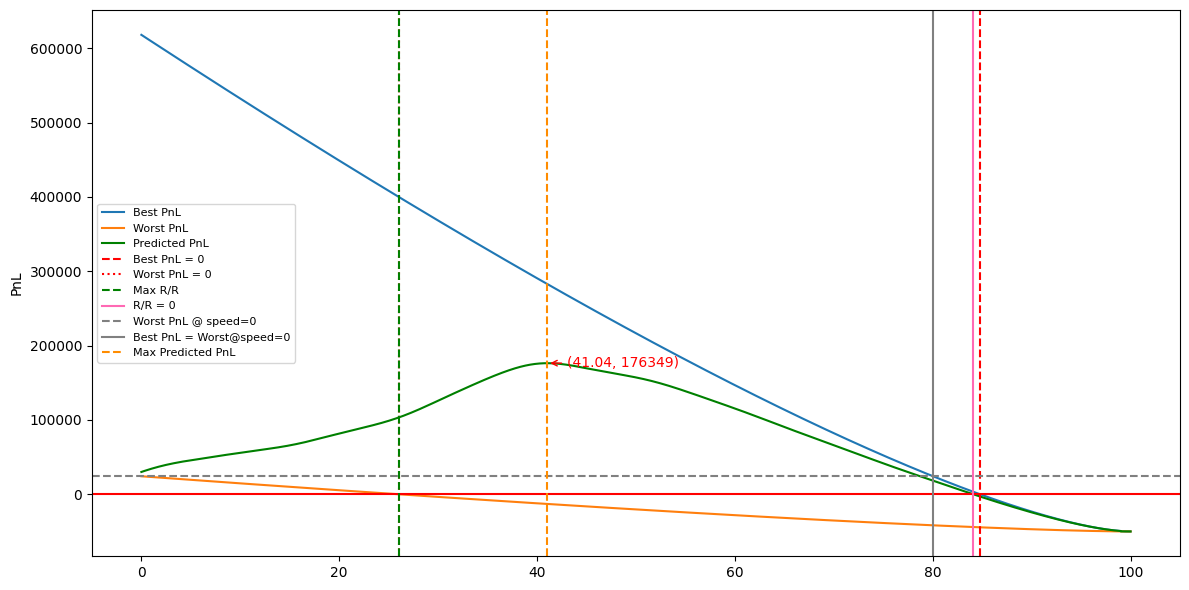

In [12]:
fig, ax1 = _base()
ax1.plot(speed, prediction, label='Predicted PnL', color='green')
ax1.axhline(y=0, color='r', linestyle='-')
ax1.axvline(x=best_zero,  color='red', linestyle='--', label='Best PnL = 0')
ax1.axvline(x=worst_zero, color='red', linestyle=':',  label='Worst PnL = 0')
ax1.axvline(x=rr_max_x,   color='green',   linestyle='--', label='Max R/R')
ax1.axvline(x=rr_zero,    color='hotpink', linestyle='-',  label='R/R = 0')
ax1.axhline(y=h_val, color='gray', linestyle='--', label='Worst PnL @ speed=0')
ax1.axvline(x=x_h_best, color='gray', linestyle='-', label='Best PnL = Worst@speed=0')
ax1.axvline(x=pred_max_x, color='darkorange', linestyle='--', label='Max Predicted PnL')
ax1.annotate(f'({pred_max_x:.2f}, {pred_max_y:.0f})',
             xy=(pred_max_x, pred_max_y),
             xytext=(pred_max_x + 2, pred_max_y - 5000),
             color='red',
             arrowprops=dict(arrowstyle='->', color='red'))

x_ints = np.arange(25, 44)
y_ints = np.interp(x_ints, speed_arr[::-1], pred_arr[::-1])
# ax1.scatter(x_ints, y_ints, color='gray', zorder=5, s=30, label='Integer speed 25–43')

_legend(ax1)
plt.tight_layout()
plt.show()